In [17]:
from neurocore.shared import set_global_style
set_global_style()

In [18]:
from pathlib import Path
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [19]:
# ---------------------------
# User-facing configuration
# ---------------------------
MOUSE_GROUP = "NAC_CORE_6"
DO_STANDARDIZE = True
MIN_ROWS_PER_MODEL = 1

WIN_VS_GO_NONBASELINE_COLS = [
    # co-var
    "current_choice",
    "phase_num",
    "whole_trial_time",
    "whole_trial_velocity",
    "same_choice_in_to_last_out",
    # "trial_id",
    "cum_trial_id",
    # y
    "mean_dff_after_out",
    # random var
    "mouse_id",
    # "opponent_id",
]

WIN_VS_GO_BASELINE_COLS = [
    # co-var
    "current_choice",
    "whole_trial_time",
    "whole_trial_velocity",
    "same_choice_in_to_last_out",
    # "trial_id",
    # y
    "mean_dff_after_out",
    # random var
    "mouse_id",
]

WITHIN_WIN_NONBASELINE_COLS = [
    # co-var
    "current_choice",
    "phase_num",
    "whole_trial_time",
    "whole_trial_velocity",
    "same_choice_in_to_last_out",
    # "trial_id",
    "cum_trial_id",
    # special within-win co-var
    "day_meet_this_opponent_times",
    "cumulative_meet_this_opponent_times",
    # y
    "mean_dff_after_out",
    # random var
    "mouse_id",
    "opponent_id",
]

WITHIN_WIN_BASELINE_COLS = [
    # co-var
    "current_choice",
    "whole_trial_time",
    "whole_trial_velocity",
    "same_choice_in_to_last_out",
    # "trial_id",
    "cum_trial_id",
    # special within-win co-var
    "day_meet_this_opponent_times",
    "cumulative_meet_this_opponent_times",
    # y
    "mean_dff_after_out",
    # random var
    "mouse_id",
    "opponent_id",
]

# Columns to standardize if DO_STANDARDIZE is set to True
STANDARDIZE_COLS = [
    "phase_num",
    "whole_trial_time",
    "whole_trial_velocity",
    # "trial_id",
    "cum_trial_id",
    "same_choice_in_to_last_out",
    "day_meet_this_opponent_times",
    "cumulative_meet_this_opponent_times",
]

In [20]:
def safe_to_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def zscore_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col not in out.columns:
            continue
        s = pd.to_numeric(out[col], errors="coerce")
        sd = s.std(ddof=0)
        if pd.notna(sd) and sd > 0:
            out[col] = (s - s.mean()) / sd
    return out


def prepare_base_dataframe(mouse_group: str, do_standardize: bool) -> pd.DataFrame:
    data_path = "./data/DA/processed/DA_dataset.pkl"
    raw = pd.read_pickle(data_path)

    df = raw[raw["mouse_group"] == mouse_group].copy()
    df = df.dropna(subset=["event_dff_out"]).copy()

    df["mean_dff_after_out"] = df["event_dff_out"].apply(lambda x: np.mean(x[100:]))
    df["mean_dff_after_out_NAc"] = df["event_dff_out"].apply(lambda x: np.mean(x[75:150]))

    phase_str = df["phase_id"].astype(str).str.strip()
    df["phase_num"] = pd.to_numeric(phase_str.str.extract(r"(\d+)$")[0], errors="coerce")

    numeric_cols = [
        "phase_num",
        "whole_trial_time",
        "whole_trial_velocity",
        "trial_id",
        "cum_trial_id",
        "same_choice_in_to_last_out",
        "day_meet_this_opponent_times",
        "cumulative_meet_this_opponent_times",
        "mean_dff_after_out",
        "mean_dff_after_out_NAc",
    ]

    df = safe_to_numeric(df, numeric_cols)
    df["mouse_id"] = df["mouse_id"].astype(str)
    df["current_choice"] = df["current_choice"].astype(str).str.lower().str.strip()

    if do_standardize:
        df = zscore_columns(df, STANDARDIZE_COLS)

    return df


df_base = prepare_base_dataframe(
    mouse_group=MOUSE_GROUP,
    do_standardize=DO_STANDARDIZE,
)

print("Prepared dataframe shape:", df_base.shape)
print("brain_region values:", sorted(df_base["brain_region"].dropna().unique().tolist()))
print("phase_id values:", sorted(df_base["phase_id"].dropna().astype(str).unique().tolist()))

phase_nonnull = df_base["phase_num"].dropna()
print("phase_num non-null count:", int(phase_nonnull.shape[0]))
if not phase_nonnull.empty:
    print("phase_num range:", (float(phase_nonnull.min()), float(phase_nonnull.max())))

Prepared dataframe shape: (1369, 31)
brain_region values: ['NAc_core', 'mPFC']
phase_id values: ['baseline', 'win-1', 'win-2', 'win-3', 'win-4']
phase_num non-null count: 1145
phase_num range: (-1.2928179059439253, 1.4133548587833042)


In [ ]:
TERM_LABELS = {
    "C(current_choice, Treatment('g'))[T.w]": "Win vs. Go",
    "C(current_choice)[T.w]": "Win vs. Go",
    "phase_num": "Test Day",
    "whole_trial_time": "Trial Duration",
    "whole_trial_velocity": "Trial Velocity",
    "trial_id": "Daily Trial Order",
    "cum_trial_id": "Global Trial Order",
    "same_choice_in_to_last_out": "Inter-Trial Interval (ITI)",
    "day_meet_this_opponent_times": "Daily Opponent Novelty",
    "cumulative_meet_this_opponent_times": "Global Opponent Novelty",
}


def filter_subset(df: pd.DataFrame, brain_region: str, phase_label: str) -> pd.DataFrame:
    if phase_label == "baseline":
        mask = (df["brain_region"] == brain_region) & (df["phase_id"] == "baseline")
    else:
        mask = (df["brain_region"] == brain_region) & (df["phase_id"] != "baseline")
    return df.loc[mask].copy()


def get_target_col(brain_region: str) -> str:
    return "mean_dff_after_out" if brain_region == "mPFC" else "mean_dff_after_out_NAc"


def resolve_cols_for_target(base_cols: list[str], y_col: str) -> list[str]:
    return [y_col if col == "mean_dff_after_out" else col for col in base_cols]


def _col_to_formula_term(col: str) -> str:
    if col == "current_choice":
        return "C(current_choice)"
    return col


def build_formula_from_required_cols(required_cols: list[str], y_col: str) -> str:
    # Strictly follow the predefined column list order for fixed effects.
    excluded_cols = {y_col, "mouse_id", "opponent_id"}
    terms = [_col_to_formula_term(col) for col in required_cols if col not in excluded_cols]
    rhs = " + ".join(terms) if terms else "1"
    return f"{y_col} ~ {rhs}"


def get_case_spec(analysis_type: str, phase_label: str, y_col: str) -> tuple[str, list[str], bool]:
    if analysis_type == "win_vs_go":
        base_cols = WIN_VS_GO_NONBASELINE_COLS if phase_label == "non-baseline" else WIN_VS_GO_BASELINE_COLS
    else:
        base_cols = WITHIN_WIN_NONBASELINE_COLS if phase_label == "non-baseline" else WITHIN_WIN_BASELINE_COLS

    required_cols = resolve_cols_for_target(base_cols, y_col)
    formula = build_formula_from_required_cols(required_cols, y_col)
    use_opponent_random = "opponent_id" in required_cols

    return formula, required_cols, use_opponent_random


def fit_mixedlm_with_fallback(sub_df: pd.DataFrame, formula: str, use_opponent_random: bool):
    model_kwargs = {
        "formula": formula,
        "data": sub_df,
        "groups": sub_df["mouse_id"],
        "re_formula": "1",
    }
    if use_opponent_random:
        model_kwargs["vc_formula"] = {"opponent_id": "0 + C(opponent_id)"}

    model = smf.mixedlm(**model_kwargs)

    methods = ["lbfgs"]
    first_success = None
    last_error = None

    for method in methods:
        try:
            result = model.fit(reml=False, method=method, maxiter=1000, disp=False)
            if first_success is None:
                print(f"Successfully fitted with method '{method}'.")
                print(result.summary())
                first_success = (result, method)
            if bool(getattr(result, "converged", False)):
                return result, method, None
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"

    if first_success is not None:
        result, method = first_success
        return result, method, "No optimizer reached converged=True; returned first successful fit."

    raise RuntimeError(last_error or "All optimizers failed.")


def extract_fixed_effect_table(result) -> pd.DataFrame:
    fixed_terms = list(result.model.exog_names)
    conf_int = result.conf_int()

    rows = []
    for term in fixed_terms:
        coef = float(result.params.get(term, np.nan))
        se = float(result.bse.get(term, np.nan))
        p = float(result.pvalues.get(term, np.nan))
        ci_low = float(conf_int.loc[term, 0]) if term in conf_int.index else np.nan
        ci_high = float(conf_int.loc[term, 1]) if term in conf_int.index else np.nan
        rows.append(
            {
                "term": term,
                "label": TERM_LABELS.get(term, term),
                "coef": coef,
                "std_err": se,
                "z": coef / se if (pd.notna(coef) and pd.notna(se) and se != 0) else np.nan,
                "p_value": p,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

    return pd.DataFrame(rows)


In [6]:
def format_p_value(p: float) -> str:
    if pd.isna(p):
        return "p = NA"
    if p < 0.0001:
        return "p < 0.0001"
    return f"p = {p:.4f}"


def compact_formula_text(formula_text: str, line_width: int = 95) -> str:
    pretty = formula_text
    pretty = pretty.replace("C(current_choice, Treatment('g'))", "C(choice, Treatment('g'))")
    pretty = pretty.replace("phase_num", "phase_num")
    pretty = pretty.replace("same_choice_in_to_last_out", "ITI")
    pretty = pretty.replace("day_meet_this_opponent_times_binary", "day_novelty_binary")
    pretty = pretty.replace("cumulative_meet_this_opponent_times_binary", "global_novelty_binary")
    pretty = pretty.replace("day_meet_this_opponent_times", "day_novelty")
    pretty = pretty.replace("cumulative_meet_this_opponent_times", "global_novelty")
    wrapped = textwrap.wrap(pretty, width=line_width)
    return "\n".join(wrapped)


def plot_effect_forest(
    fixed_df: pd.DataFrame,
    formula_text: str,
    title_text: str,
    highlight_term: str | None = None,
):
    _ = highlight_term  # Kept for backward compatibility with existing call sites.

    plot_df = fixed_df[fixed_df["term"] != "Intercept"].copy()
    if plot_df.empty:
        return None

    # Sort by slope magnitude (absolute coefficient), largest shown at the top.
    plot_df["abs_coef"] = plot_df["coef"].abs()
    plot_df = plot_df.sort_values("abs_coef", ascending=False).drop(columns=["abs_coef"])
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor="#eeeeee")
    ax.set_facecolor("#eeeeee")

    y_pos = np.arange(len(plot_df))

    for i, row in plot_df.iterrows():
        is_significant = pd.notna(row["p_value"]) and row["p_value"] < 0.05
        color = "#d62728" if is_significant else "#7a7a7a"

        ax.errorbar(
            x=row["coef"],
            y=i,
            xerr=[[row["coef"] - row["ci_low"]], [row["ci_high"] - row["coef"]]],
            fmt="o",
            color=color,
            ecolor=color,
            elinewidth=2.6,
            capsize=6,
            capthick=2.3,
            markersize=10,
            zorder=3,
        )

        p_text = format_p_value(row["p_value"])
        ax.text(
            row["coef"],
            i + 0.17,
            p_text,
            color=color,
            fontsize=13,
            fontweight="bold" if is_significant else "normal",
            ha="center",
            va="bottom",
        )

    ax.axvline(0.0, color="#2f2f2f", linestyle="--", linewidth=1.6, zorder=1)
    ax.grid(axis="x", linestyle=":", alpha=0.35, color="#7f7f7f")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["label"], fontsize=17)
    ax.tick_params(axis="x", labelsize=13)

    x_min = float(np.nanmin(plot_df["ci_low"]))
    x_max = float(np.nanmax(plot_df["ci_high"]))
    x_span = max(x_max - x_min, 0.2)
    ax.set_xlim(x_min - 0.05 * x_span, x_max + 0.12 * x_span)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.text(
        0.01,
        0.985,
        compact_formula_text(formula_text, line_width=95),
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
        linespacing=1.2,
    )

    ax.set_title(
        f"{title_text}\n(Linear Mixed-Effects Model)",
        fontsize=25,
        fontweight="bold",
        pad=16,
    )
    ax.set_xlabel("Model Coefficient", fontsize=20, fontweight="bold")

    fig.subplots_adjust(left=0.22, right=0.96, bottom=0.12, top=0.81)

    plt.savefig(f"./results/DA_after_out_mixed_model/{title_text.replace(' ', '_').replace('|', '_')}.pdf", dpi=300)

    return fig

In [7]:
def run_all_models(df: pd.DataFrame) -> list[dict]:
    records = []

    analysis_types = ["win_vs_go", "within_win"]
    brain_regions = ["mPFC", "NAc_core"]
    phases = ["non-baseline"]

    for analysis_type in analysis_types:
        for brain_region in brain_regions:
            for phase_label in phases:
                y_col = get_target_col(brain_region)
                sub_df = filter_subset(df, brain_region, phase_label)

                formula, required_cols, use_opponent_random = get_case_spec(
                    analysis_type=analysis_type,
                    phase_label=phase_label,
                    y_col=y_col,
                )

                missing_cols = [col for col in required_cols if col not in sub_df.columns]
                if missing_cols:
                    records.append(
                        {
                            "analysis_type": analysis_type,
                            "brain_region": brain_region,
                            "phase": phase_label,
                            "status": "failed",
                            "reason": f"Missing required columns: {missing_cols}",
                        }
                    )
                    continue

                sub_df = sub_df.dropna(subset=required_cols).copy()

                if use_opponent_random:
                    sub_df["opponent_id"] = sub_df["opponent_id"].astype(str)

                if len(sub_df) < MIN_ROWS_PER_MODEL:
                    records.append(
                        {
                            "analysis_type": analysis_type,
                            "brain_region": brain_region,
                            "phase": phase_label,
                            "status": "skipped",
                            "reason": f"Too few rows after strict-column dropna: n={len(sub_df)}",
                        }
                    )
                    continue

                kept_terms = [term.strip() for term in formula.split("~", 1)[1].split("+")]

                try:
                    result, optimizer, fit_note = fit_mixedlm_with_fallback(
                        sub_df=sub_df,
                        formula=formula,
                        use_opponent_random=use_opponent_random,
                    )
                except Exception as exc:
                    records.append(
                        {
                            "analysis_type": analysis_type,
                            "brain_region": brain_region,
                            "phase": phase_label,
                            "status": "failed",
                            "reason": f"{type(exc).__name__}: {exc}",
                        }
                    )
                    continue

                fixed_table = extract_fixed_effect_table(result)

                model_info = pd.DataFrame(
                    [
                        {
                            "analysis_type": analysis_type,
                            "brain_region": brain_region,
                            "phase": phase_label,
                            "n_obs": int(result.nobs),
                            "optimizer": optimizer,
                            "converged": bool(getattr(result, "converged", False)),
                            "aic": float(result.aic),
                            "bic": float(result.bic),
                            "formula": formula,
                            "required_cols": ", ".join(required_cols),
                            "kept_terms": ", ".join(kept_terms),
                            "fit_note": fit_note or "",
                        }
                    ]
                )

                if analysis_type == "win_vs_go":
                    highlight_term = "C(current_choice, Treatment('g'))[T.w]"
                    title_text = f"Robustness of Win-vs-Go Effect | {brain_region} | {phase_label}"
                else:
                    highlight_term = "day_meet_this_opponent_times"
                    title_text = f"Robustness of Within-Win Effects | {brain_region} | {phase_label}"

                records.append(
                    {
                        "analysis_type": analysis_type,
                        "brain_region": brain_region,
                        "phase": phase_label,
                        "status": "ok",
                        "model_info": model_info,
                        "fixed_table": fixed_table,
                        "result": result,
                        "formula": formula,
                        "title_text": title_text,
                        "highlight_term": highlight_term,
                    }
                )

    return records


all_results = run_all_models(df_base)
print("Total result blocks:", len(all_results))
print("ok blocks:", sum(r.get("status") == "ok" for r in all_results))
print("failed/skipped blocks:", sum(r.get("status") != "ok" for r in all_results))

Successfully fitted with method 'lbfgs'.
                       Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       mean_dff_after_out
No. Observations:        563           Method:                   ML                
No. Groups:              6             Scale:                    0.6995            
Min. group size:         56            Log-Likelihood:           inf               
Max. group size:         112           Converged:                Yes               
Mean group size:         93.8                                                      
-----------------------------------------------------------------------------------
                           Coef.    Std.Err.    z    P>|z|    [0.025       0.975]  
-----------------------------------------------------------------------------------
Intercept                   0.000 2451919.486  0.000 1.000 -4805673.886 4805673.886
C(current_choice)[T.w]      0.640       0.077  8.298 0.000

In [16]:
all_results[0]['title_text']

'Robustness of Win-vs-Go Effect | mPFC | non-baseline'

In [8]:
# ---------------------------
# 8 model result tables (statsmodels original summary)
# ---------------------------
for i, item in enumerate(all_results, start=1):
    print("=" * 110)
    print(
        f"[{i}] analysis={item['analysis_type']} | region={item['brain_region']} | phase={item['phase']} | status={item['status']}"
    )

    if item["status"] != "ok":
        print("Reason:", item.get("reason", "N/A"))
        continue

    # Directly show the built-in statsmodels regression table
    print(item["result"].summary())

[1] analysis=win_vs_go | region=mPFC | phase=non-baseline | status=ok
                       Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       mean_dff_after_out
No. Observations:        563           Method:                   ML                
No. Groups:              6             Scale:                    0.6995            
Min. group size:         56            Log-Likelihood:           inf               
Max. group size:         112           Converged:                Yes               
Mean group size:         93.8                                                      
-----------------------------------------------------------------------------------
                           Coef.    Std.Err.    z    P>|z|    [0.025       0.975]  
-----------------------------------------------------------------------------------
Intercept                   0.000 2451919.486  0.000 1.000 -4805673.886 4805673.886
C(current_choice)[T.w]      0

                        Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       mean_dff_after_out_NAc
No. Observations:       500           Method:                   ML                    
No. Groups:             5             Scale:                    27.7472               
Min. group size:        90            Log-Likelihood:           inf                   
Max. group size:        112           Converged:                Yes                   
Mean group size:        100.0                                                         
--------------------------------------------------------------------------------------
                           Coef.    Std.Err.     z    P>|z|     [0.025       0.975]   
--------------------------------------------------------------------------------------
Intercept                   0.000 13929854.013  0.000 1.000 -27302012.176 27302012.176
C(current_choice)[T.w]      2.126        0.518  4.104 0.000         

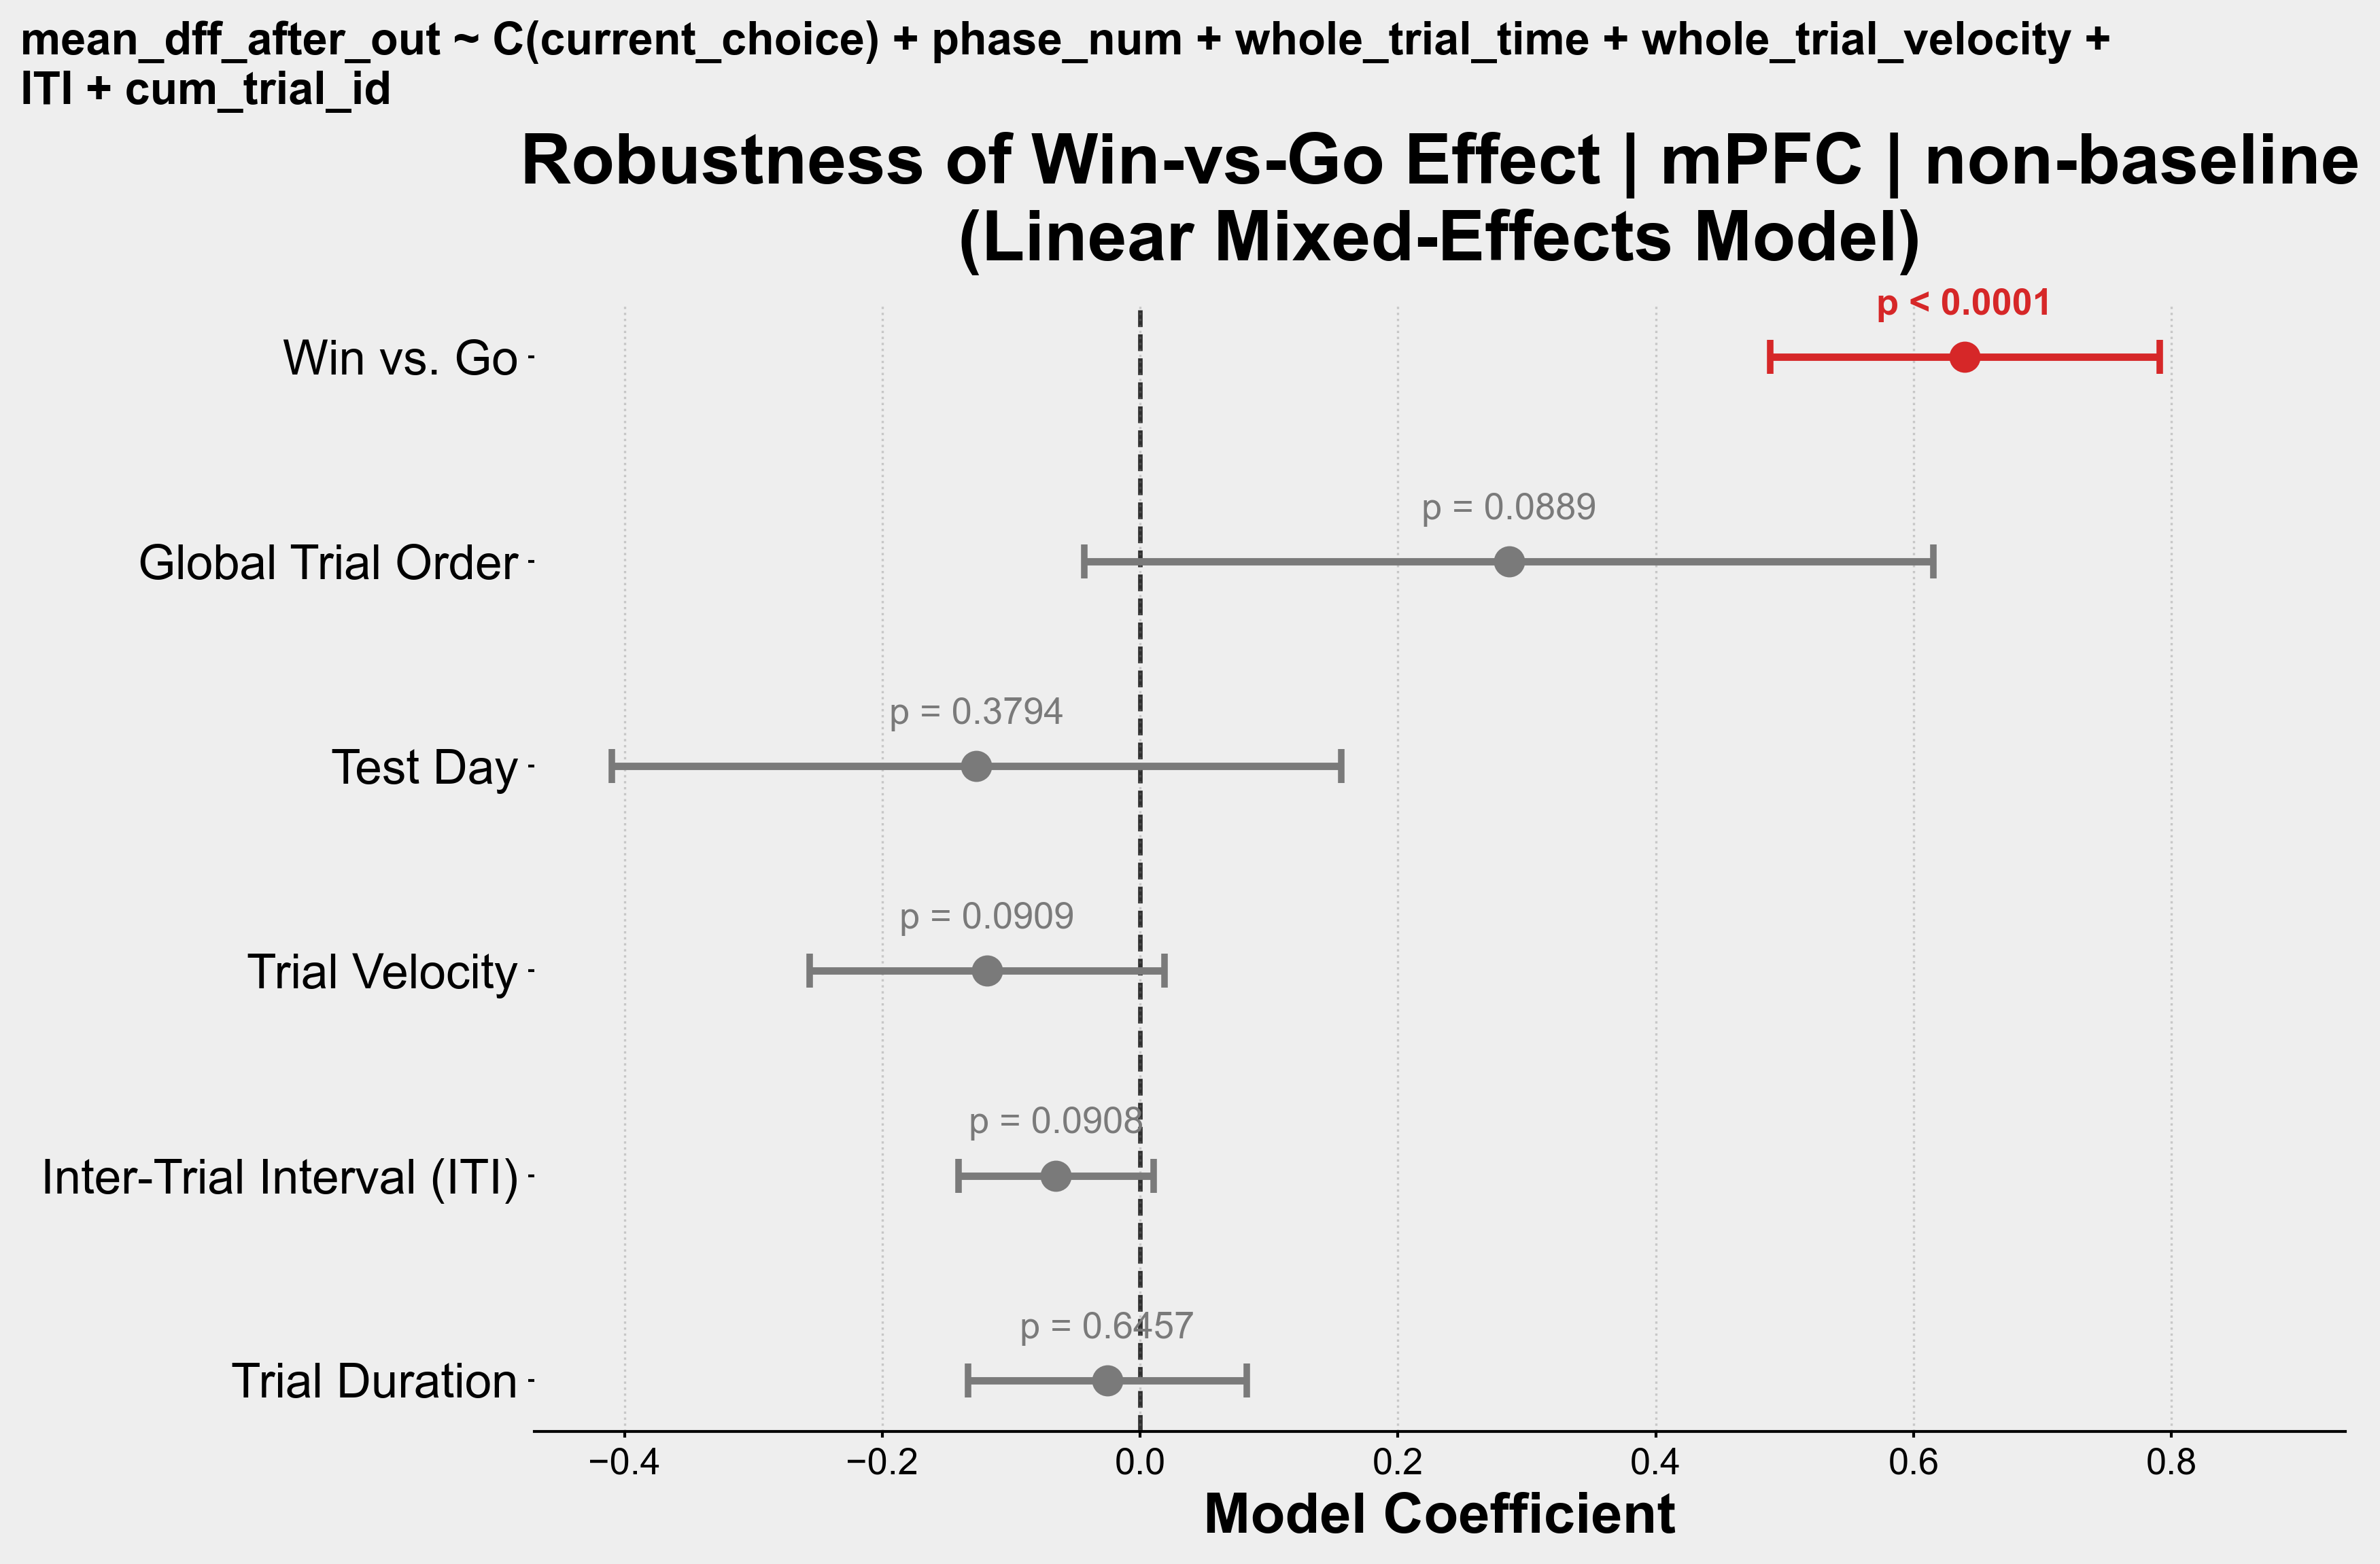

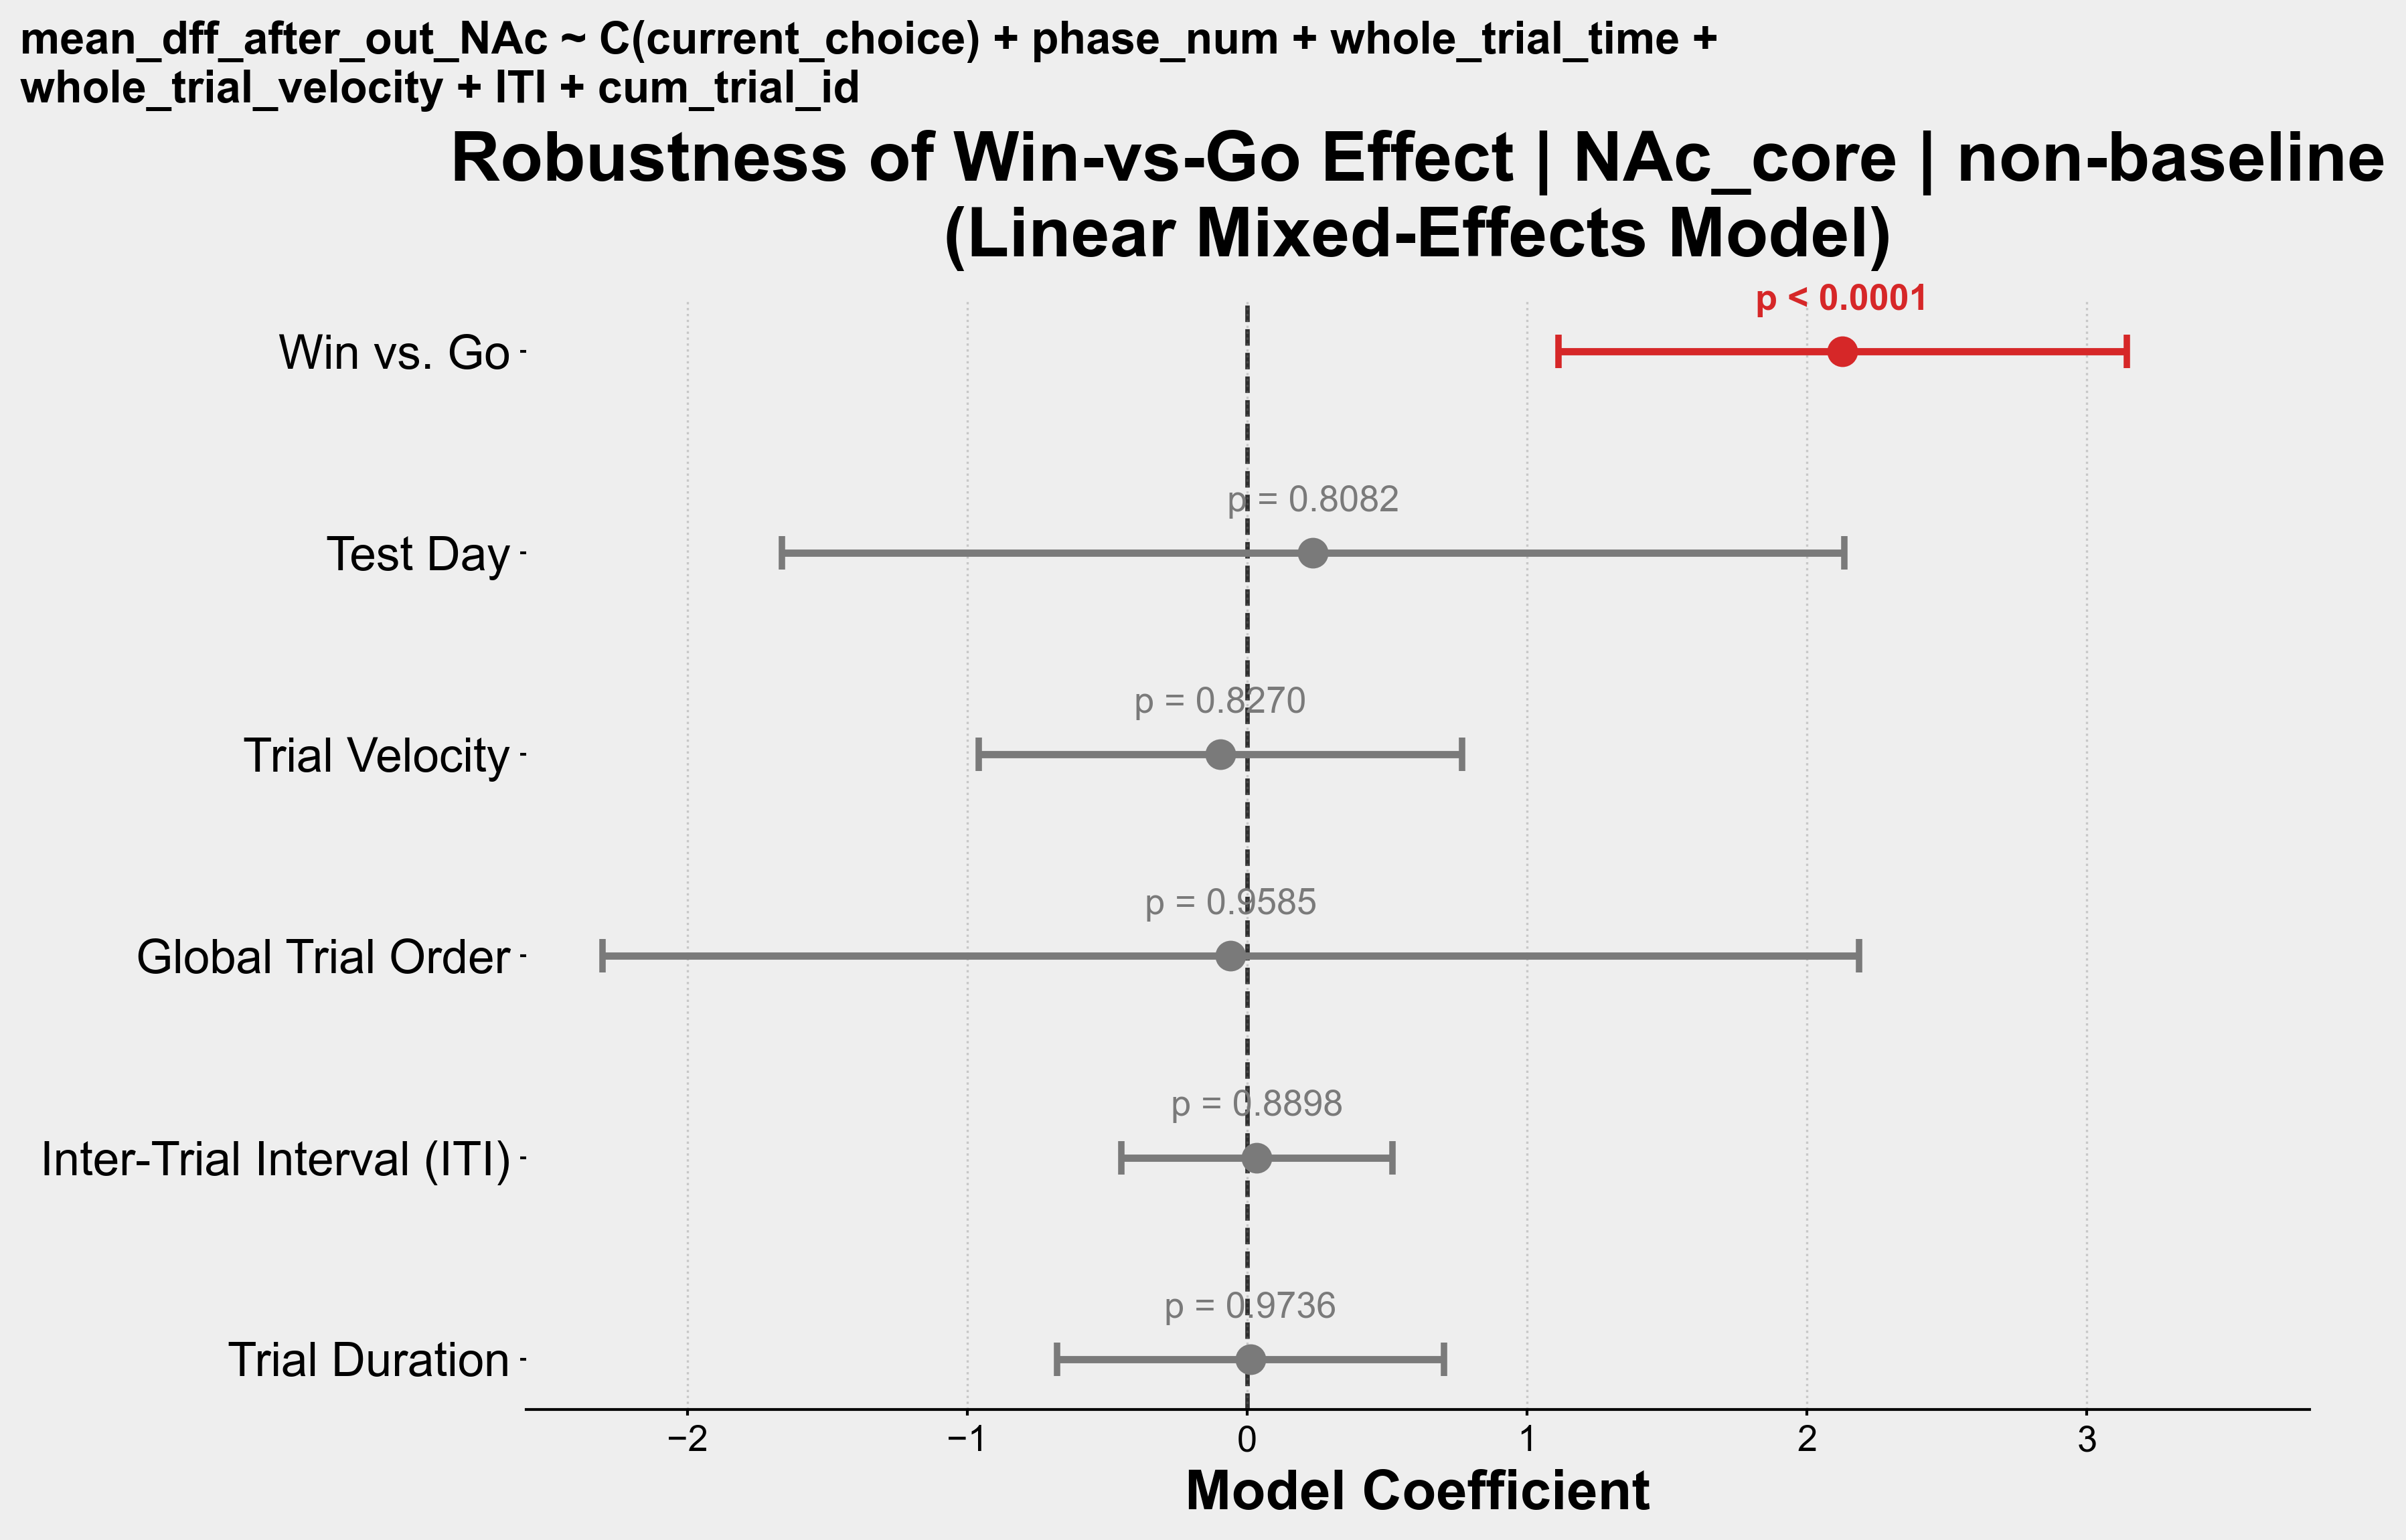

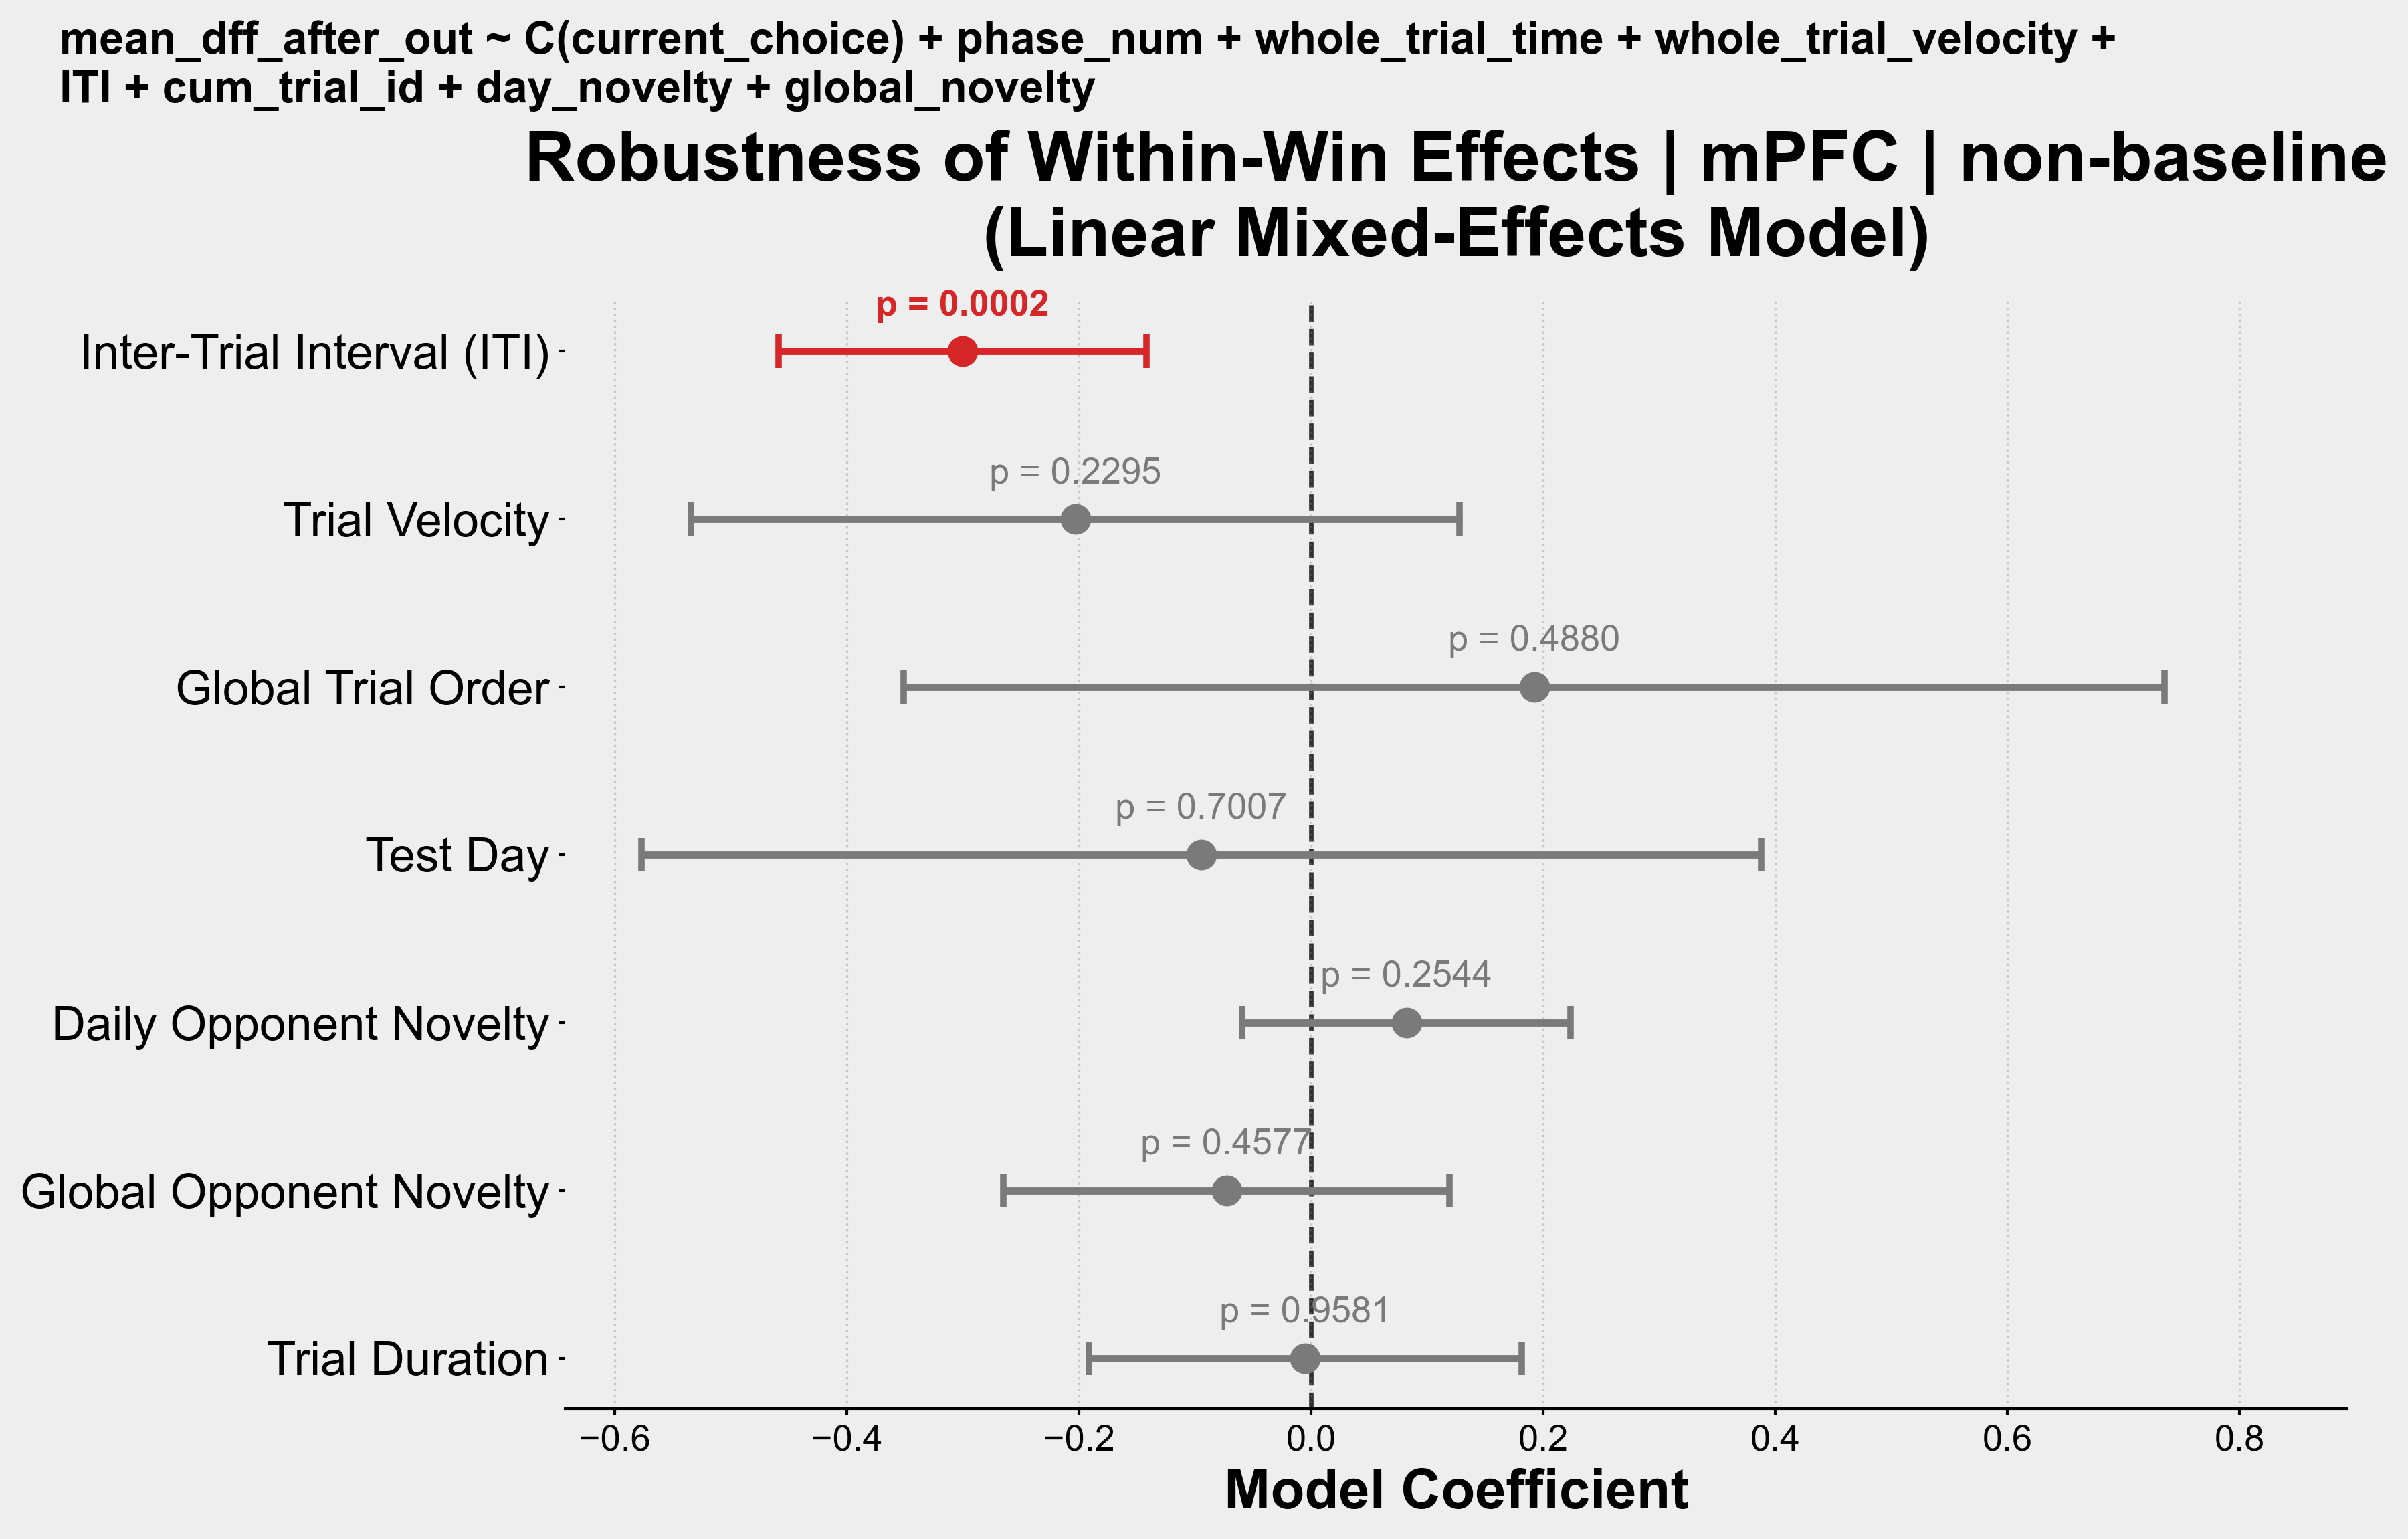

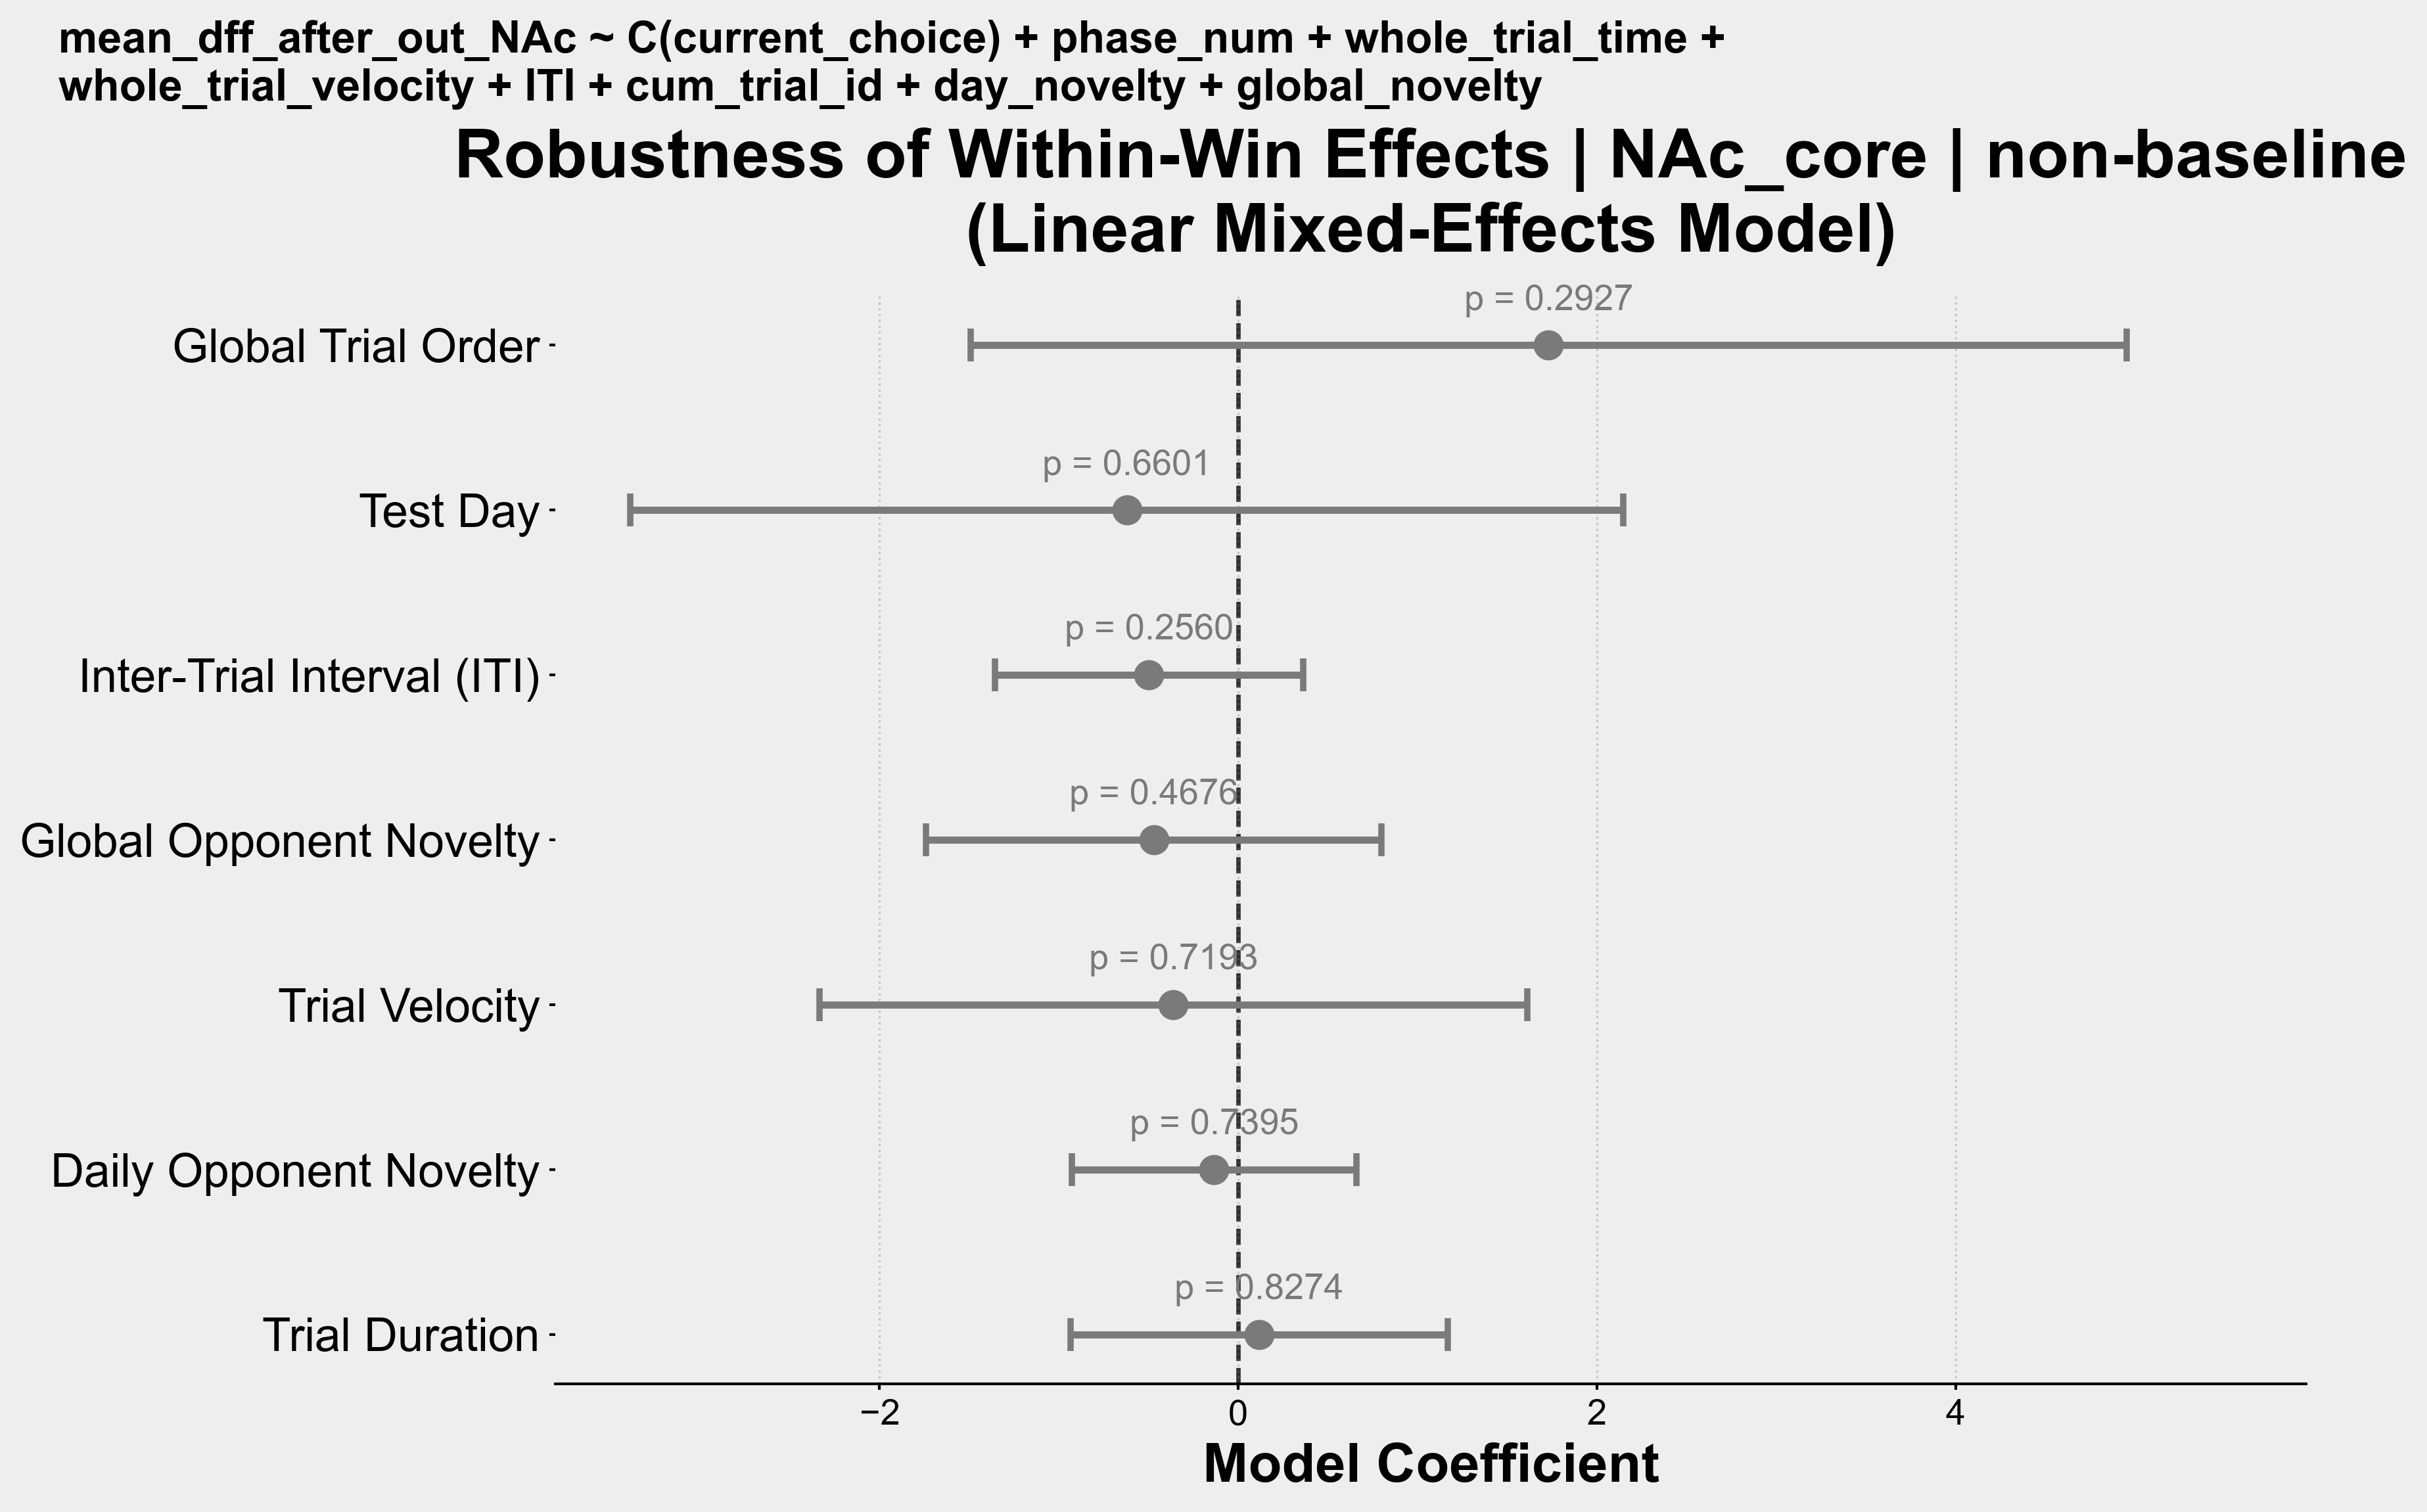

In [9]:
# ---------------------------
# 8 attached-style forest plots
# ---------------------------
figures = []

for item in all_results:
    if item.get("status") != "ok":
        continue

    fig = plot_effect_forest(
        fixed_df=item["fixed_table"],
        formula_text=item["formula"],
        title_text=item["title_text"],
        highlight_term=item["highlight_term"],
    )
    if fig is not None:
        figures.append((item, fig))
        set_global_style()
        plt.show()

In [10]:
# Optional export: CSV tables + PNG figures
EXPORT_OUTPUTS = True

if EXPORT_OUTPUTS:
    out_dir = Path("./exp/fig3D_after_out_mixedModel/results")
    out_dir.mkdir(parents=True, exist_ok=True)

    for idx, item in enumerate(all_results, start=1):
        tag = f"DA_{item['analysis_type']}_{item['brain_region']}_{item['phase']}"

        if item.get("status") != "ok":
            pd.DataFrame([{
                "status": item.get("status"),
                "reason": item.get("reason", ""),
            }]).to_csv(out_dir / 'table' / f"{tag}_status.csv", index=False)
            continue

        item["model_info"].to_csv(out_dir / 'table' / f"{tag}_model_info.csv", index=False)
        item["fixed_table"].to_csv(out_dir / 'table' / f"{tag}_fixed_effects.csv", index=False)

    for idx, (item, fig) in enumerate(figures, start=1):
        tag = f"DA_{item['analysis_type']}_{item['brain_region']}_{item['phase']}"
        fig.savefig(out_dir / 'fig' / 'png' / f"{tag}_forest.pdf", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
        fig.savefig(out_dir / 'fig' / 'pdf' / f"{tag}_forest.pdf", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Exported outputs to: {out_dir.resolve()}")
else:
    print("Set EXPORT_OUTPUTS = True to write tables and figures to disk.")

OSError: Cannot save file into a non-existent directory: 'exp\fig3D_after_out_mixedModel\results\table'